# 💰 Prediksi Pendapatan
Melatih model regresi untuk memprediksi nilai `sales` berdasarkan produk, wilayah, diskon, dan status tren.
Output: model regresi disimpan ke dalam `encoders.pkl` (digabung) atau file terpisah.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='darkgrid')
print('✅ Library siap')

✅ Library siap


## 1. Load Data & Feature Engineering

In [2]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin'] = df['profit'] / df['sales']
df['revenue_per_unit'] = df['sales'] / df['quantity']
df['log_sales'] = np.log1p(df['sales'])

print(f'Data dimuat: {df.shape}')
print(f'\nTarget (sales) stats:')
print(df['sales'].describe().round(0))

Data dimuat: (5000, 20)

Target (sales) stats:
count      5000.0
mean     106733.0
std       85108.0
min         264.0
25%       39767.0
50%       83080.0
75%      156969.0
max      398485.0
Name: sales, dtype: float64


## 2. EDA Target Variable

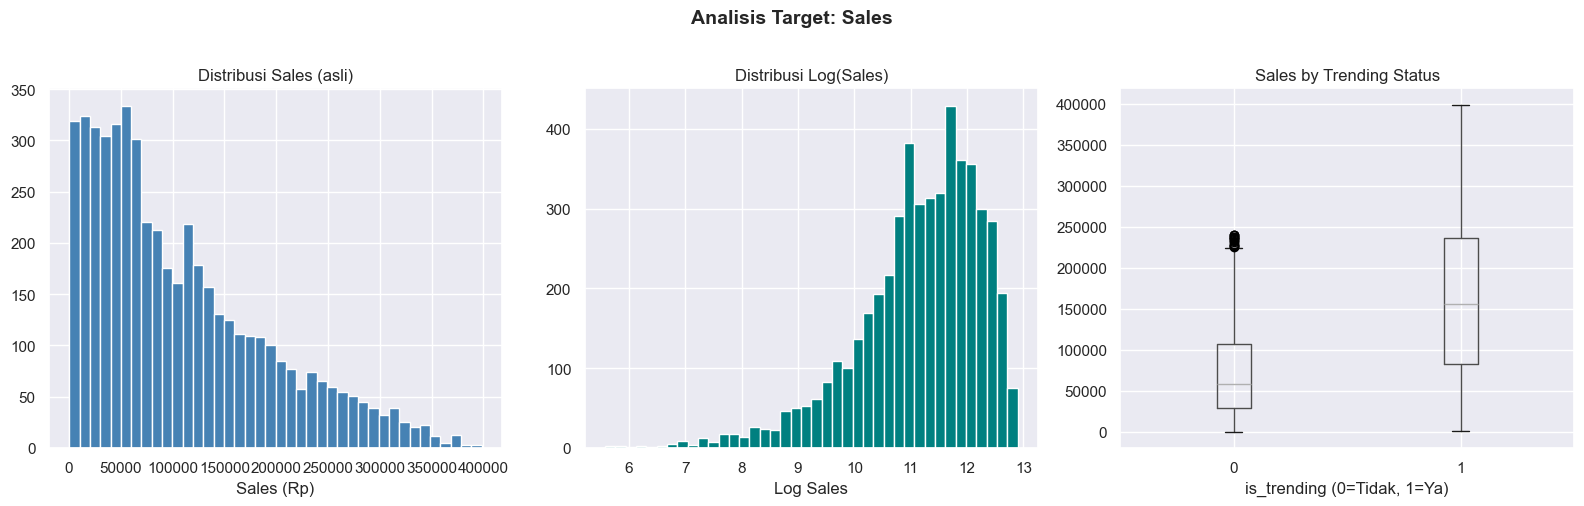

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi sales
axes[0].hist(df['sales'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Sales (asli)')
axes[0].set_xlabel('Sales (Rp)')

# Log sales
axes[1].hist(df['log_sales'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('Distribusi Log(Sales)')
axes[1].set_xlabel('Log Sales')

# Sales per is_trending
df.boxplot(column='sales', by='is_trending', ax=axes[2])
axes[2].set_title('Sales by Trending Status')
axes[2].set_xlabel('is_trending (0=Tidak, 1=Ya)')
plt.suptitle('')

plt.suptitle('Analisis Target: Sales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

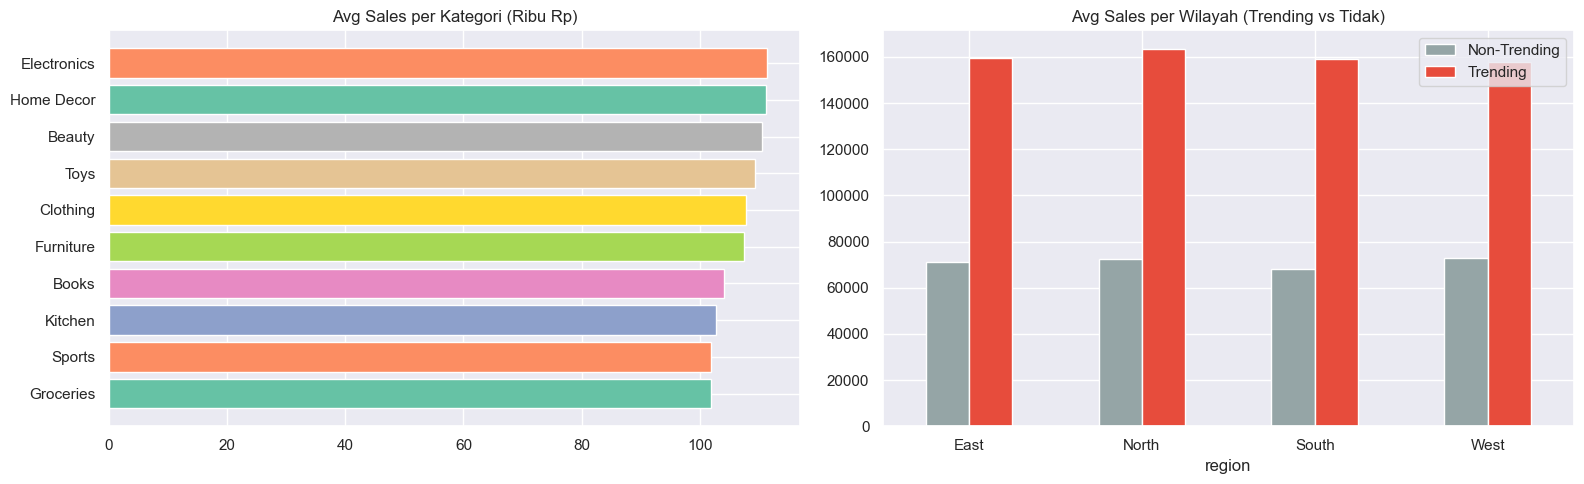

In [4]:
# Sales per kategori + wilayah
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_sales = df.groupby('category')['sales'].mean().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values/1000, color=sns.color_palette('Set2'))
axes[0].set_title('Avg Sales per Kategori (Ribu Rp)')

reg_sales = df.groupby(['region','is_trending'])['sales'].mean().unstack()
reg_sales.plot(kind='bar', ax=axes[1], color=['#95a5a6','#e74c3c'], rot=0)
axes[1].set_title('Avg Sales per Wilayah (Trending vs Tidak)')
axes[1].legend(['Non-Trending','Trending'])

plt.tight_layout()
plt.show()

## 3. Encoding Fitur

In [5]:
# Load encoder dari notebook 02 jika ada
try:
    with open('../Notebooks/encoders.pkl', 'rb') as f:
        le_dict = pickle.load(f)
    print('✅ Encoder dimuat dari encoders.pkl')
except:
    le_dict = {}
    for col in ['region','city','category','sub_category','payment_mode']:
        le = LabelEncoder()
        le.fit(df[col])
        le_dict[col] = le
    print('✅ Encoder dibuat baru')

df_enc = df.copy()
for col in ['region','city','category','sub_category','payment_mode']:
    df_enc[col+'_enc'] = le_dict[col].transform(df[col])

FEATURES_REG = [
    'quantity', 'unit_price', 'discount', 'month', 'year',
    'is_trending', 'profit_margin', 'revenue_per_unit',
    'region_enc', 'city_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

X = df_enc[FEATURES_REG]
y = df_enc['log_sales']  # target = log(sales)
print(f'Shape: X={X.shape}')

✅ Encoder dimuat dari encoders.pkl
Shape: X=(5000, 13)


## 4. Split & Training Model

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

models = {
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression' : Ridge(alpha=1.0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)   # balik dari log ke rupiah
    y_true = np.expm1(y_test)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name] = {'model': model, 'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f'[{name}]  R²={r2:.4f}  MAE=Rp {mae:,.0f}  RMSE=Rp {rmse:,.0f}')

Train: 4,000 | Test: 1,000
[Random Forest]  R²=1.0000  MAE=Rp 258  RMSE=Rp 473
[Gradient Boosting]  R²=0.9994  MAE=Rp 1,477  RMSE=Rp 2,171
[Ridge Regression]  R²=0.7151  MAE=Rp 27,485  RMSE=Rp 46,534


## 5. Evaluasi Model Terbaik

🏆 Model Terbaik: Random Forest
   R²   : 1.0000
   MAE  : Rp 258
   RMSE : Rp 473


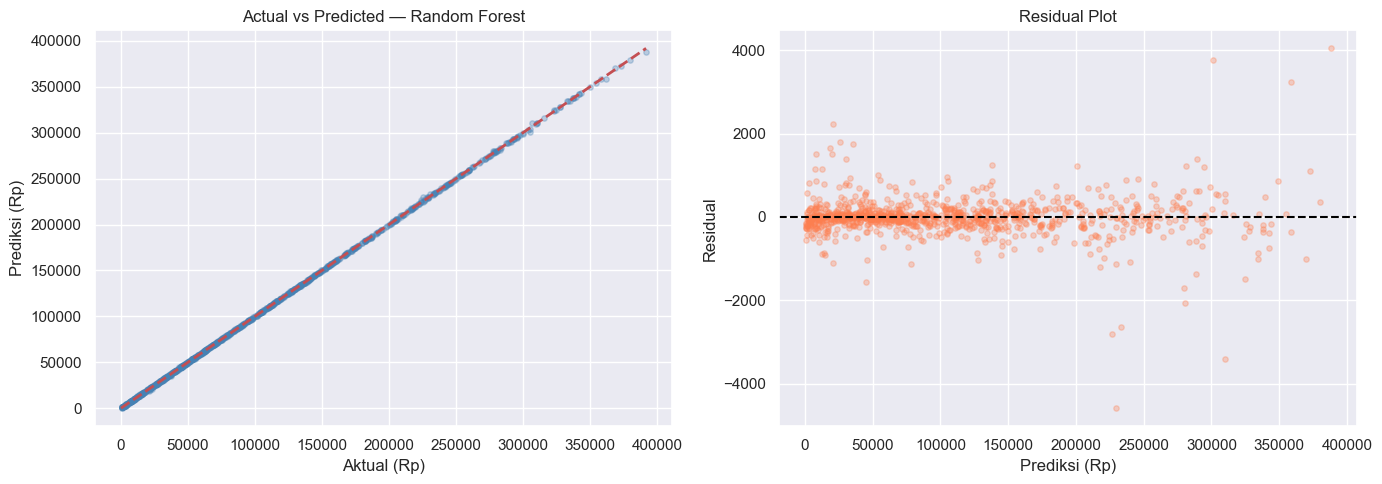

In [7]:
best_name = max(results, key=lambda x: results[x]['r2'])
best_model = results[best_name]['model']

y_pred_best = np.expm1(best_model.predict(X_test))
y_true_best = np.expm1(y_test)

print(f'🏆 Model Terbaik: {best_name}')
print(f'   R²   : {results[best_name]["r2"]:.4f}')
print(f'   MAE  : Rp {results[best_name]["mae"]:,.0f}')
print(f'   RMSE : Rp {results[best_name]["rmse"]:,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, color='steelblue', s=15)
max_val = max(y_true_best.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_xlabel('Aktual (Rp)')
axes[0].set_ylabel('Prediksi (Rp)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')

# Residual plot
residuals = y_true_best.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, color='coral', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Prediksi (Rp)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

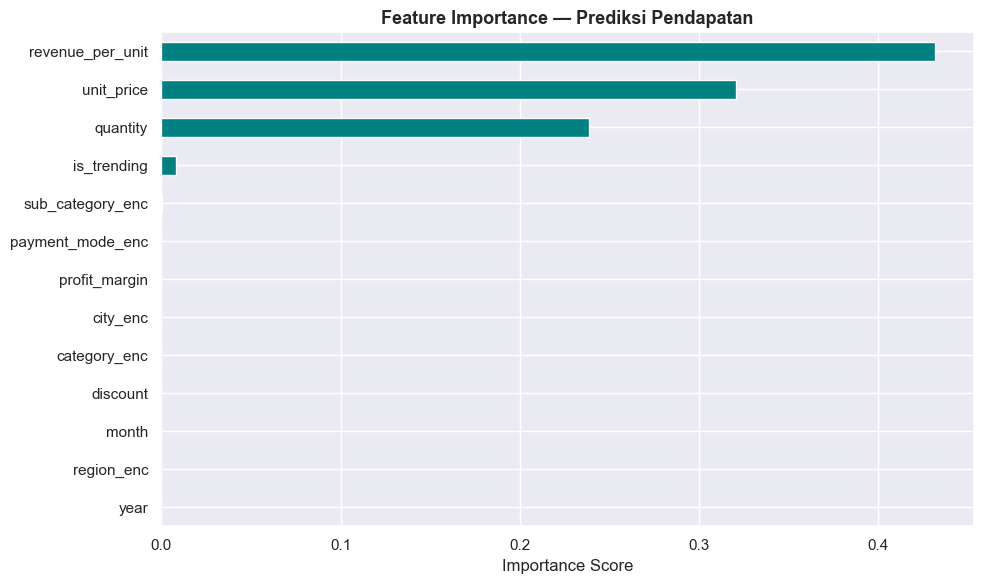

In [8]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES_REG).sort_values()
    fig, ax = plt.subplots(figsize=(10, 6))
    fi.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Feature Importance — Prediksi Pendapatan', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

## 6. Simulasi Prediksi per Region & Kategori

In [9]:
def safe_enc(le, val):
    try: return int(le.transform([val])[0])
    except: return 0

summary = []
for region in df['region'].unique():
    for cat in df['category'].unique():
        for trending in [0, 1]:
            sub = df[(df['region']==region) & (df['category']==cat)]
            if len(sub) == 0: continue
            row = {
                'quantity'        : sub['quantity'].mean(),
                'unit_price'      : sub['unit_price'].mean(),
                'discount'        : sub['discount'].mean(),
                'month'           : 6, 'year': 2025,
                'is_trending'     : trending,
                'profit_margin'   : (sub['profit']/sub['sales']).mean(),
                'revenue_per_unit': (sub['sales']/sub['quantity']).mean(),
                'region_enc'      : safe_enc(le_dict['region'], region),
                'city_enc'        : 0,
                'category_enc'    : safe_enc(le_dict['category'], cat),
                'sub_category_enc': 0,
                'payment_mode_enc': 0
            }
            pred = np.expm1(best_model.predict(pd.DataFrame([row])[FEATURES_REG])[0])
            summary.append({'Region': region, 'Kategori': cat,
                            'Status': 'Trending' if trending else 'Non-Trending',
                            'Prediksi Sales': pred})

df_sim = pd.DataFrame(summary)
top10 = df_sim[df_sim['Status']=='Trending'].sort_values('Prediksi Sales', ascending=False).head(10)
print('🏆 TOP 10 Peluang Pendapatan Tertinggi (Produk Trending):')
print(top10.to_string(index=False))

🏆 TOP 10 Peluang Pendapatan Tertinggi (Produk Trending):
Region    Kategori   Status  Prediksi Sales
 North    Clothing Trending   139681.581301
 North  Home Decor Trending   136311.319437
  West Electronics Trending   135907.363501
  East Electronics Trending   133160.575936
 South       Books Trending   132699.898525
  West   Furniture Trending   131897.591548
 North   Furniture Trending   131733.371638
 South      Beauty Trending   131502.428663
 North      Beauty Trending   130916.228292
 South      Sports Trending   128138.113429


## 7. Simpan Model Prediksi Pendapatan

In [10]:
# Update encoders.pkl dengan model regresi sekalian
try:
    with open('../Notebooks/encoders.pkl', 'rb') as f:
        existing = pickle.load(f)
except:
    existing = le_dict

# Simpan model regresi terpisah
with open('../Notebooks/encoders.pkl', 'wb') as f:
    pickle.dump({
        **existing,
        'reg_model'   : best_model,
        'features_reg': FEATURES_REG
    }, f)

print('✅ Model regresi ditambahkan ke encoders.pkl')
print(f'   📦 Model: {best_name}')
print(f'   📌 R²: {results[best_name]["r2"]:.4f}')
print(f'   📌 MAE: Rp {results[best_name]["mae"]:,.0f}')
print()
print('✅ Notebook Prediksi Pendapatan selesai!')

✅ Model regresi ditambahkan ke encoders.pkl
   📦 Model: Random Forest
   📌 R²: 1.0000
   📌 MAE: Rp 258

✅ Notebook Prediksi Pendapatan selesai!
